In [27]:
import cv2
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt




In [28]:
def imgProcessing(raw_images):
    
    processed_imgs = []
    listaaux=[]
    
    for raw in raw_images:
        thred = cv2.adaptiveThreshold(raw, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
        thred_inv = 255 - thred
        
        
        contours, _ = cv2.findContours(thred_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for cont in contours:
            x, y, w, h = cv2.boundingRect(cont)
            #cv2.rectangle(thred, (x, y), (x + w, y + h), (0, 255, 0), 1)
        
        rec_resize = cv2.resize(thred_inv[y:y+h+2, x:x+w+2], (25, 25))
        listaaux.append(rec_resize)
        processed_imgs.append(np.array(rec_resize).reshape(-1) / 255.0)
        
    final_array = np.array(processed_imgs)
        
    return final_array, listaaux
    

In [33]:
character_classes = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
n_classes = len(character_classes)
classes_dict = {}

i = 0

for char in character_classes:
    classes_dict.setdefault(char, i)
    i+=1
    
print(classes_dict['B'])
print(len(character_classes))

11
36


In [34]:
charr = 'Z'
print(charr.isalpha())

True


In [35]:
#cargamos imágenes LETRAS
import os

train_directory = "train_ocr"

train_images = []
img_classes = []

for character_class in character_classes:
    if(character_class.isdecimal()):
        class_directory = os.path.join(train_directory, character_class)
    elif(character_class.isalpha()):
        if(character_class.isupper()):
            subdir = "mayúsculas"
        else:
            subdir = "minúsculas"
        class_directory = os.path.join(train_directory, subdir, character_class)
        print(class_directory)

    for filename in os.listdir(class_directory):
        image_path = os.path.join(class_directory, filename)
        image = cv2.imread(image_path)
        assert image is not None, "file could not be read, check with os.path.exists()"
        
        train_images.append(cv2.cvtColor(image,cv2.COLOR_BGR2GRAY))
        img_classes.append(classes_dict[character_class])

y_train = np.array(img_classes)
x_train, recortes = imgProcessing(train_images)

print(y_train)
#print(x_train[30000])


train_ocr/mayúsculas/A
train_ocr/mayúsculas/B
train_ocr/mayúsculas/C
train_ocr/mayúsculas/D
train_ocr/mayúsculas/E
train_ocr/mayúsculas/F
train_ocr/mayúsculas/G
train_ocr/mayúsculas/H
train_ocr/mayúsculas/I
train_ocr/mayúsculas/J
train_ocr/mayúsculas/K
train_ocr/mayúsculas/L
train_ocr/mayúsculas/M
train_ocr/mayúsculas/N
train_ocr/mayúsculas/O
train_ocr/mayúsculas/P
train_ocr/mayúsculas/Q
train_ocr/mayúsculas/R
train_ocr/mayúsculas/S
train_ocr/mayúsculas/T
train_ocr/mayúsculas/U
train_ocr/mayúsculas/V
train_ocr/mayúsculas/W
train_ocr/mayúsculas/X
train_ocr/mayúsculas/Y
train_ocr/mayúsculas/Z
[ 0  0  0 ... 35 35 35]


In [36]:
print(len(recortes))
print(len(x_train))
plt.imshow(recortes[38749], cmap="gray")
plt.show()

22500
22500


IndexError: list index out of range

In [25]:
test_directory = "validation_ocr"

test_images = []
test_classes = []

for character_class in character_classes:
    class_directory = os.path.join(test_directory, character_class)
    for filename in os.listdir(class_directory):
        image_path = os.path.join(class_directory, filename)
        image = cv2.imread(image_path)
        assert image is not None, "file could not be read, check with os.path.exists()"
        
        test_images.append(cv2.cvtColor(image,cv2.COLOR_BGR2GRAY))
        test_classes.append(classes_dict[character_class])

y_test = np.array(test_classes)
x_test, recortes_test = imgProcessing(test_images)

9000
9000
0


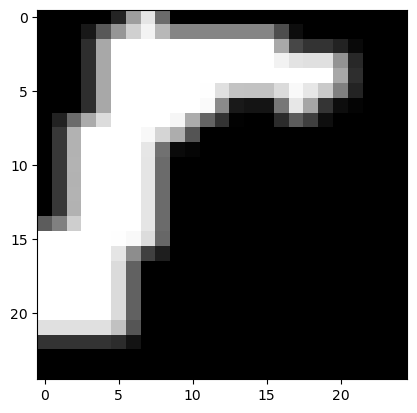

In [26]:
print(len(recortes_test))
print(len(x_test))
print(len(recortes_test) % 250)
plt.imshow(recortes_test[6875], cmap="gray")
plt.show()

In [27]:
print(x_train.shape)
print(len(character_classes*625))
print(len(y_train))
print(y_train.shape)

(22500, 625)
22500
22500
(22500,)


In [28]:
print(x_test.shape)
print(len(y_test))

(9000, 625)
9000


In [29]:
#ENTRENAMIENTO Y EVALUACIÓN MULTICLASE
#from sklearn.model_selection import train_test_split
#x,_,y,_=train_test_split(x_train,y_train,test_size=0.8)
#print(len(x)/len(x_train))
#print(x.shape)
#print(np.unique(y))
#print(np.bincount(y))
#print(np.bincount(y)/len(y))

<h3>LDA + KNN</h3>

<h4>LDA</h4>

In [30]:
print(x_train.shape)
print(y_train.shape)

(22500, 625)
(22500,)


In [31]:
print(y_train[22000])

35


In [60]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
#Entrenamos
lda.fit(x_train,y_train)

#Proyectar
Z = lda.transform(x_train)
print(Z.shape)

(22500, 35)


In [61]:
print(lda.score(x_train,y_train))
ypred = lda.predict(x_train)
print(ypred)

0.9631111111111111
[ 0  0  0 ... 35 21 35]


In [66]:
print(lda.score(x_test,y_test))
y_test_predict = lda.predict(x_test)
print(len(y_test_predict))

z_test = lda.transform(x_test)


0.9603333333333334
9000


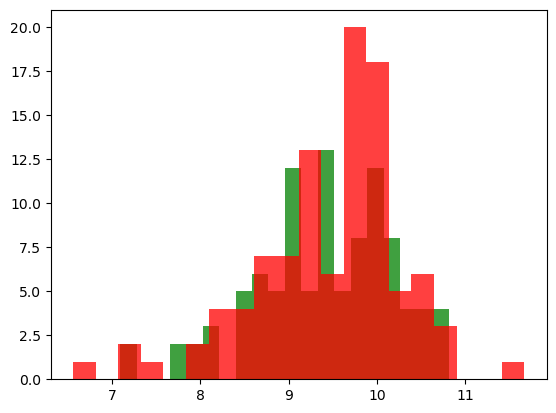

In [35]:
plt.hist(Z[0:100,0], 20,
facecolor='green', alpha=0.75)
plt.hist(Z[100:200,0], 20,
facecolor='red', alpha=0.75)
plt.show()

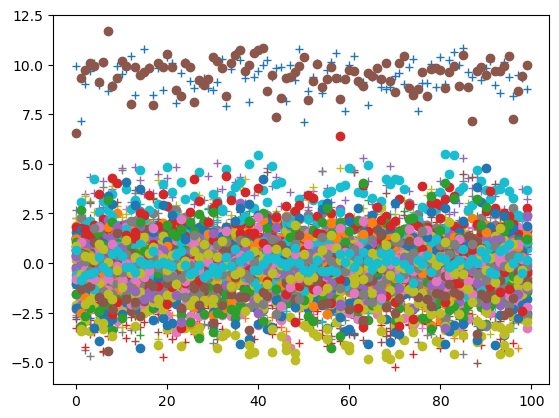

In [36]:
XT = lda.transform(x_train)
plt.plot(XT[0:100],'+')
plt.plot(XT[100:200],'o')
plt.show()

In [37]:
from sklearn.neighbors import KNeighborsClassifier

#Elegimos numero de vecinos
n_neighbors=3

#Creamos Clasificador
knn = KNeighborsClassifier(n_neighbors)
knn.fit(Z,y_train)

print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(Z, y_train)))

print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(z_test, y_test)))

Accuracy of K-NN classifier on training set: 0.97
Accuracy of K-NN classifier on test set: 0.97


In [42]:
from sklearn import metrics

#Predicciones del conjunto de test
pred_knn=knn.predict(z_test)
pred_proba=knn.predict_proba(z_test)
#Métricas del clasificador

print("ACCURACY:", accuracy_score(y_test,pred_knn))
print("PRECISION: ", metrics.precision_score(y_test,pred_knn,average='weighted'))
print("RECALL: ", metrics.recall_score(y_test,pred_knn,average='weighted'))
print("F1-SCORE: ",metrics.f1_score(y_test,pred_knn,average='weighted'))

#Alternativa
print(metrics.classification_report(y_test,pred_knn))



ACCURACY: 0.9673333333333334
PRECISION:  0.9721781258373621
RECALL:  0.9673333333333334
F1-SCORE:  0.9628852208156313
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       250
           1       0.98      0.98      0.98       250
           2       1.00      1.00      1.00       250
           3       1.00      1.00      1.00       250
           4       1.00      1.00      1.00       250
           5       1.00      1.00      1.00       250
           6       1.00      1.00      1.00       250
           7       1.00      1.00      1.00       250
           8       1.00      1.00      1.00       250
           9       1.00      1.00      1.00       250
          10       0.92      1.00      0.96       250
          11       1.00      1.00      1.00       250
          12       1.00      1.00      1.00       250
          13       1.00      0.99      0.99       250
          14       1.00      1.00      1.00       250
          15     

In [43]:
cm = np.round(confusion_matrix(y_test, pred_knn, normalize='all'),3)
cmd = ConfusionMatrixDisplay(cm, display_labels=character_classes)
#plt.figure().set_figwidth(18)
#cmd.plot()
#plt.show()

print("AUC", metrics.roc_auc_score(y_test,pred_proba,multi_class='ovr'))

AUC 0.9874999174603174


<h3>LDA + Gaussiano Naïve</h3>

<h4>Entrenamiento Gaussiano Naïve</h4>

In [44]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(Z, y_train)

zgnb_predict = gnb.predict(z_test)
zgnb_prob_predict = gnb.predict_proba(z_test)

In [45]:
print("Accuracy z_test: ", gnb.score(z_test, y_test))
print("Accuracy z_test prob: ", metrics.accuracy_score(y_test, zgnb_predict))

Accuracy z_test:  0.961
Accuracy z_test prob:  0.961


In [46]:
print(metrics.roc_auc_score(y_test, zgnb_prob_predict, multi_class='ovr'))

0.997611650793651


In [47]:
#Precision, recall, f1-score por clase
print(metrics.classification_report(y_test, zgnb_predict))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       250
           1       0.98      0.94      0.96       250
           2       1.00      0.98      0.99       250
           3       0.99      1.00      0.99       250
           4       1.00      1.00      1.00       250
           5       0.98      1.00      0.99       250
           6       1.00      1.00      1.00       250
           7       1.00      1.00      1.00       250
           8       1.00      1.00      1.00       250
           9       1.00      1.00      1.00       250
          10       1.00      1.00      1.00       250
          11       1.00      1.00      1.00       250
          12       1.00      1.00      1.00       250
          13       1.00      0.98      0.99       250
          14       1.00      1.00      1.00       250
          15       1.00      0.92      0.96       250
          16       0.94      0.94      0.94       250
          17       0.99    

<h3>PCA + KNN<h/h3>

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=200)
pca.fit(x_train)
z_pca = pca.transform(x_train)

In [49]:
print("Autovalores")
print("***********")
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
print("Autovectores")
print("***********")
print(pca.components_)

Autovalores
***********
[12.58636668  9.27466723  7.29205716  6.15403163  5.63294868  4.56566432
  3.61125618  3.03619706  2.77392014  2.60974277  2.32243298  1.8691194
  1.84306694  1.73165606  1.42534264  1.3916209   1.13961678  1.02400216
  1.00461732  0.8076212   0.70504033  0.66959355  0.65070755  0.55485977
  0.5369435   0.50268997  0.46484592  0.42380489  0.40145525  0.38254208
  0.37159567  0.34124149  0.31548539  0.29647136  0.27747914  0.27148894
  0.2649363   0.24546632  0.23521286  0.23329998  0.21188877  0.20138747
  0.19126522  0.18635244  0.1841563   0.17819115  0.16970812  0.16657796
  0.16319166  0.15912473  0.15246661  0.14913887  0.14634916  0.13806353
  0.13587653  0.12794912  0.12460475  0.12266649  0.11825526  0.11425512
  0.11337998  0.11022391  0.10445621  0.10262213  0.09989662  0.09725785
  0.09681886  0.09519277  0.09287654  0.09024667  0.08660714  0.08495044
  0.08264744  0.0816716   0.08061322  0.07794783  0.07699956  0.07635758
  0.07350875  0.07235288  0.

In [50]:
#Varianza en los primeros 50 elementos
result = np.sum(pca.explained_variance_ratio_[:50])
print(result)

0.9073923012635812


In [51]:
#pca.fit(x_test, y_test)

z_pca_test = pca.transform(x_test)

In [52]:
knn2 = KNeighborsClassifier(n_neighbors)
knn.fit(z_pca, y_train)

print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(z_pca, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(z_pca_test, y_test)))

Accuracy of K-NN classifier on training set: 0.97
Accuracy of K-NN classifier on test set: 0.97


In [53]:
#Predicciones del conjunto de test
pred_knn2=knn.predict(z_pca_test)
pred_proba2=knn.predict_proba(z_pca_test)
#Métricas del clasificador

print("ACCURACY:", metrics.accuracy_score(y_test,pred_knn2))
print("PRECISION: ", metrics.precision_score(y_test,pred_knn2,average='weighted'))
print("RECALL: ", metrics.recall_score(y_test,pred_knn2,average='weighted'))
print("F1-SCORE: ",metrics.f1_score(y_test,pred_knn2,average='weighted'))

ACCURACY: 0.9681111111111111
PRECISION:  0.9738377355366596
RECALL:  0.9681111111111111
F1-SCORE:  0.963458075885362


In [54]:
#Alternativa
print(metrics.classification_report(y_test,pred_knn2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       250
           1       0.97      0.98      0.98       250
           2       1.00      1.00      1.00       250
           3       0.99      1.00      0.99       250
           4       1.00      1.00      1.00       250
           5       1.00      1.00      1.00       250
           6       1.00      1.00      1.00       250
           7       1.00      1.00      1.00       250
           8       1.00      1.00      1.00       250
           9       1.00      1.00      1.00       250
          10       0.92      1.00      0.96       250
          11       1.00      1.00      1.00       250
          12       1.00      1.00      1.00       250
          13       1.00      0.99      0.99       250
          14       1.00      1.00      1.00       250
          15       0.99      0.98      0.98       250
          16       1.00      1.00      1.00       250
          17       1.00    

<h3>PCA + Gaussian Naïve</h3>

In [55]:
gnb2 = GaussianNB()
gnb2.fit(z_pca, y_train)

zgnb_predict2 = gnb2.predict(z_pca_test)
zgnb_pred_prob2 = gnb2.predict_proba(z_pca_test)


In [56]:
print(zgnb_predict2.shape)
print(zgnb_pred_prob2.shape)

(9000,)
(9000, 36)


In [57]:
print("Accuracy",gnb2.score(z_pca_test,y_test))
print("Accuracy",metrics.accuracy_score(y_test, zgnb_predict2))

Accuracy 0.95
Accuracy 0.95


In [58]:
#AUC
print(metrics.roc_auc_score(y_test, zgnb_pred_prob2, multi_class='ovr'))

0.9966212253968254


In [59]:
#Precision, recall, f1-socre por clase
print(metrics.classification_report(y_test, zgnb_predict2))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       250
           1       0.91      0.86      0.88       250
           2       1.00      0.98      0.99       250
           3       1.00      1.00      1.00       250
           4       1.00      1.00      1.00       250
           5       1.00      1.00      1.00       250
           6       1.00      1.00      1.00       250
           7       0.97      1.00      0.99       250
           8       1.00      1.00      1.00       250
           9       1.00      1.00      1.00       250
          10       1.00      0.99      1.00       250
          11       0.99      1.00      0.99       250
          12       1.00      1.00      1.00       250
          13       1.00      0.99      0.99       250
          14       1.00      1.00      1.00       250
          15       0.93      0.96      0.94       250
          16       0.88      0.96      0.92       250
          17       0.99    

In [360]:
#cargamos imágenes PANELES

panels_directory = "test_ocr_panels"

panels = []

for filename in os.listdir(panels_directory):
    if filename[len(filename) - 1] != 't':
        filepath = os.path.join(panels_directory, filename)
        image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        panels.append(image)
    else:
        print(filename)

gt.txt


In [361]:
#FUNCION custom de umbralización: *PARA PANELES* con MSER y filtrando por aspect ratio
def customThreshold(images):
    thr_imgs = []
    mserletters = cv2.MSER_create(5, 60, 450, 0.25, 0.2, 200)
    for img in images:
        thimg = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
            #contours, _ = cv2.findContours(thimg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            
        regions, _ = mserletters.detectRegions(thimg)
        filtered_regions = []
        #print(len(contours))
        for rg in regions:
            x, y, w, h = cv2.boundingRect(rg)
            if (w) > (h):
                if w < 3 * h:
                    if rg is not None:
                        filtered_regions.append(rg)
        thr_imgs.append(thimg)

    return thr_imgs, filtered_regions

74


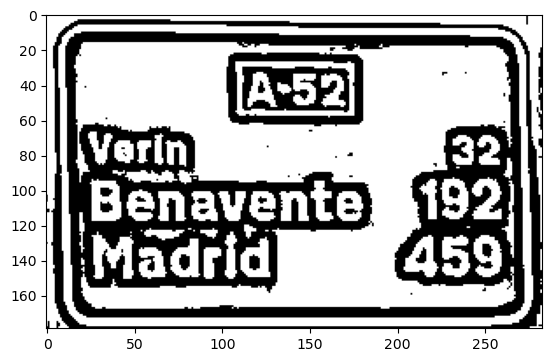

In [364]:
#train_images_threshold = customThreshold(panels)

print(len(panels))

threshold_panels, pan_regions = customThreshold(panels)

        

plt.imshow(threshold_panels[0], cmap="gray")
plt.show()